In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib  # for loading saved models
import shap
from lime.lime_tabular import LimeTabularExplainer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.inspection import PartialDependenceDisplay

shap.initjs()

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
merged_df = pd.read_csv("/Users/palakkakani/Desktop/ML/data/processed/merged_cleaned.csv")


In [3]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 42 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   user_id                 7043 non-null   object 
 1   gender                  7043 non-null   object 
 2   SeniorCitizen           7043 non-null   int64  
 3   Partner                 7043 non-null   object 
 4   Dependents              7043 non-null   object 
 5   months_active           7043 non-null   int64  
 6   PhoneService            7043 non-null   object 
 7   MultipleLines           7043 non-null   object 
 8   InternetService         7043 non-null   object 
 9   OnlineSecurity          7043 non-null   object 
 10  OnlineBackup            7043 non-null   object 
 11  DeviceProtection        7043 non-null   object 
 12  TechSupport             7043 non-null   object 
 13  StreamingTV             7043 non-null   object 
 14  StreamingMovies         7043 non-null   

In [4]:
# Target and feature columns
y = merged_df['churn_label']
drop_cols = [
    'user_id', 'churn_label', 'experiment_group', 'experiment_start_month',
    'stage_signup', 'stage_active', 'stage_engaged', 'stage_retained'
]
X = merged_df.drop(columns=drop_cols)

In [5]:
# One-hot encode categorical variables
X = pd.get_dummies(X, drop_first=True)

In [6]:
# Load saved models and scaler from training notebook
rf_model = joblib.load("RandomForest_churn_model.pkl")
xgb_model = joblib.load("XGBoost_churn_model.pkl")
log_model = joblib.load("Logistic_churn_model.pkl")
dt_model = joblib.load("DecisionTree_churn_model.pkl")
scaler = joblib.load("scaler.pkl")  # for Logistic Regression

In [8]:
import pickle
with open("feature_columns.pkl", "rb") as f:
    feature_cols = pickle.load(f)

In [9]:
X = X[feature_cols]
X_numeric = X.astype(float)

In [11]:
# Train-test split for analysis
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X_numeric, y, test_size=0.2, stratify=y, random_state=42
)

In [12]:
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [13]:
# Prepare models dictionary
models = {
    "Logistic": log_model,
    "Decision Tree": dt_model,
    "Random Forest": rf_model,
    "XGBoost": xgb_model
}

In [15]:
results = []
for name, model in models.items():
    X_test_model = X_test_scaled if name == "Logistic" else X_test
    y_pred = model.predict(X_test_model)
    y_prob = model.predict_proba(X_test_model)[:,1]

    # Save metrics
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "ROC_AUC": roc_auc_score(y_test, y_prob)
    })

In [16]:
results_df = pd.DataFrame(results).sort_values("ROC_AUC", ascending=False)
print("Model Performance Comparison:")
display(results_df)

Model Performance Comparison:


,Model,Accuracy,Precision,Recall,ROC_AUC
0,Logistic,0.803407,0.656958,0.542781,0.842385
2,Random Forest,0.805536,0.678571,0.508021,0.841572
3,XGBoost,0.791341,0.632450,0.510695,0.828071
1,Decision Tree,0.781405,0.605096,0.508021,0.811331


/var/folders/5f/yfl9x7p9311gz93ctr_bp39m0000gn/T/ipykernel_58765/3345705240.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=feature_importances.head(15), palette='viridis')


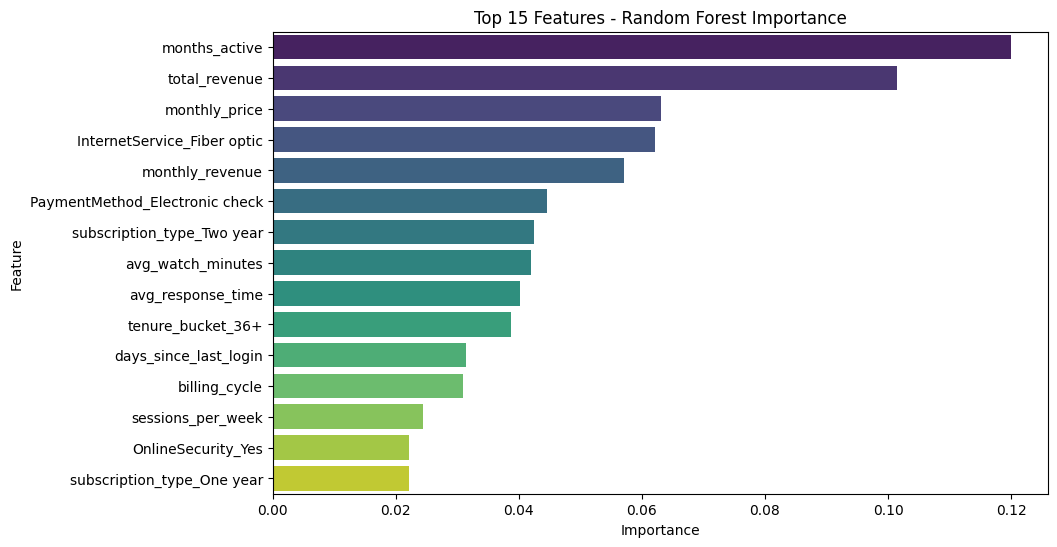

In [17]:
# Random Forest Feature Importance
feature_importances = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_
}).sort_values(by='importance', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x='importance', y='feature', data=feature_importances.head(15), palette='viridis')
plt.title("Top 15 Features - Random Forest Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

More months active → lower churn risk. Users active longer tend to stay.

Higher total revenue → lower churn risk. Paying more overall means less likely to churn.

Very low or moderate price → lower churn risk; very high price → churn risk rises. Suggests users may churn if monthly cost is too high.

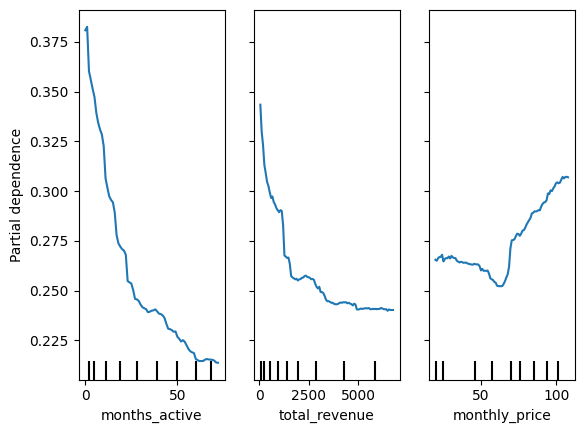

In [19]:
# Partial Dependence for top 3 features
top_features = feature_importances.head(3)['feature'].tolist()
PartialDependenceDisplay.from_estimator(rf_model, X_test, features=top_features)
plt.show()

Negative SHAP value means the feature pushes prediction towards No churn.

Positive SHAP value means the feature pushes prediction towards Churn.

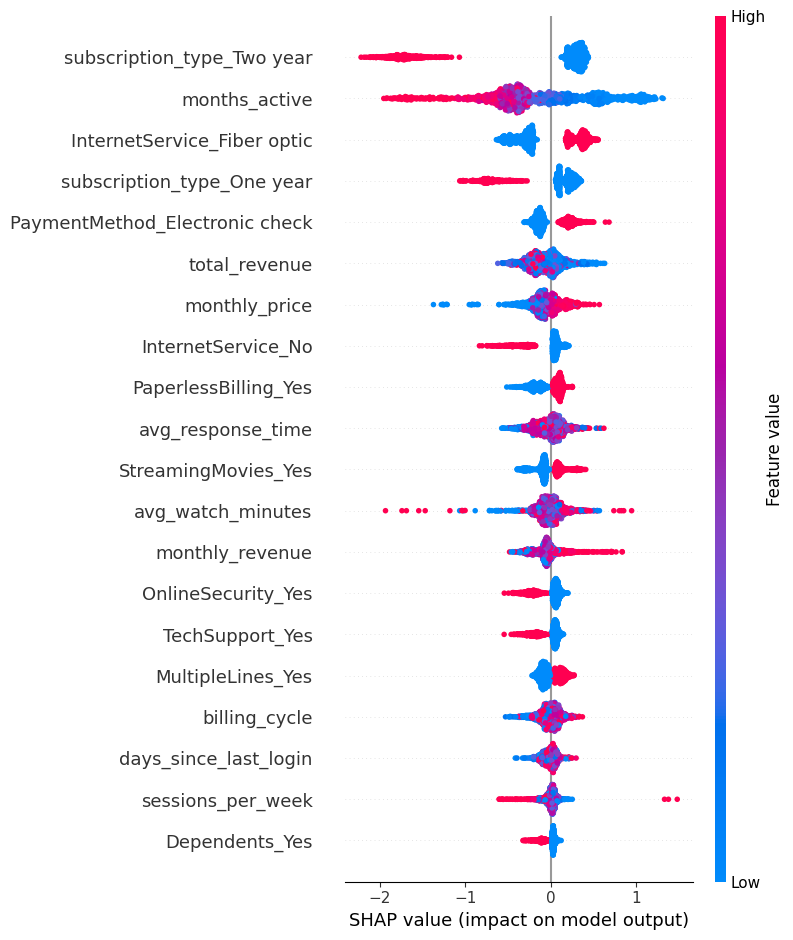

In [ ]:
# SHAP Interpretability (XGBoost example)
explainer_xgb = shap.TreeExplainer(xgb_model)
shap_values_xgb = explainer_xgb.shap_values(X_test)

# Beeswarm plot
shap.summary_plot(shap_values_xgb, X_test, plot_type="dot")


#Two-year subscription strongly reduces churn risk.
#More months active → lower churn risk, confirming PDP results.
#Users with fiber optic service tend to churn more.
#Users paying by electronic check are more likely to churn.
#High monthly price increases churn risk.

In [22]:
# LIME example (using scaled data for Logistic Regression)
explainer = LimeTabularExplainer(
    training_data=X_train_scaled,
    feature_names=X.columns,
    class_names=['No Churn','Churn'],
    mode='classification'
)

i = 5  # example user index
exp = explainer.explain_instance(
    data_row=X_test_scaled[i],
    predict_fn=rf_model.predict_proba,  # could use xgb_model.predict_proba too
    num_features=10
)
exp.show_in_notebook(show_table=True)

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
